In [27]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial, comb
from qutip import * #basis, ket2dm, displace, tensor, qeye, destroy

## 1. Ideal PNR detection

##### 1.1 No loss and dark counts


u=0.7
P: [0.34761 0.04469 0.29373 0.21453 0.07729]

u=1.0
P: [0.36788 0.      0.18394 0.24525 0.13795]

u=1.25
P: [0.35813 0.01791 0.10072 0.2285  0.17633]

u=1.5
P: [0.3347  0.05578 0.04184 0.18827 0.19611]

u=2.0
P: [0.27067 0.13534 0.      0.09022 0.18045]


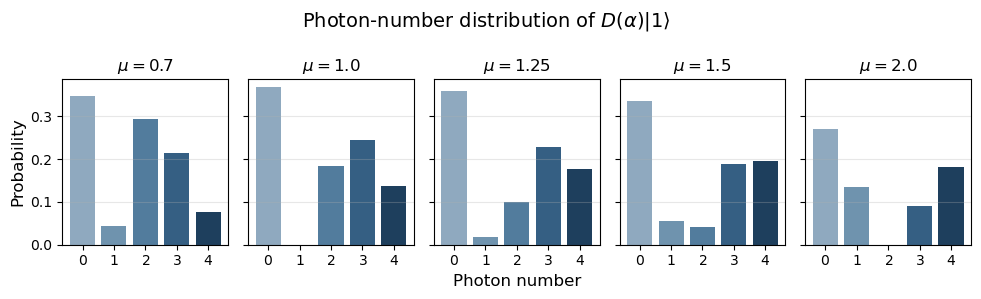

In [28]:
N = 20                       # Fock-space cutoff
us = [0.7, 1.0, 1.25, 1.5, 2.0]
n_show = 5

fig, axes = plt.subplots(1, len(us), figsize=(10, 3), sharey=True)

colors = [
    "#8FA9BF",  # p1
    "#6F93AE",  # p2
    "#527C9D",  # p3
    "#355F83",  # p4
    "#1E3F5D",  # p5
]


for ax, u in zip(axes, us):
    alpha = np.sqrt(u)       # u = |alpha|^2
    psi = displace(N, alpha) * basis(N, 1)    #Construct the displaced single-photon state, one-photon state |1>
    p = np.abs(psi.full().ravel())**2

    ax.bar(range(n_show), p[:n_show], color=colors)
    ax.set_title(rf"$\mu={u}$", fontsize=12)
    ax.set_xticks(range(n_show),
                  [rf"${n}$" for n in range(n_show)], fontsize=10)

    ax.grid(axis="y", alpha=0.3)

    print(f"\nu={u}")
    print("P:", np.round(p[:n_show], 5))

axes[0].set_ylabel("Probability", fontsize=12)
axes[2].set_xlabel("Photon number", fontsize=12)
fig.suptitle(r"Photon-number distribution of $D(\alpha)|1\rangle$", fontsize=14)
fig.tight_layout()

fig.savefig("pnr_losses_ideal.png", dpi=300, bbox_inches="tight")
plt.show()

##### 1.2 With losses and dark counts

Set `eta_pre` for loss before displacement and `eta_post` for loss/detection inefficiency after displacement.

Detector dark counts are modeled as an independent Poisson process with mean $\lambda_{\rm dark}=R_{\rm dark}\tau_{\rm on}$ per trial.

$|1\rangle$
$\xrightarrow{\eta_{\rm pre}}$
$\rho_{\rm in}$
$\xrightarrow{D(\alpha)}$
$P(n)$
$\xrightarrow{\eta_{\rm post}}$
$P_{\rm loss}(n)$
$\xrightarrow{\eta_d}$
$P_{\rm det}(n)$

In [29]:
from scipy.stats import poisson

eta_ws = [1.0, 0.8, 0.5]
us = [0.7, 1.0, 1.25, 2.0]  # mu = |alpha|^2
phi_w = 0.0


vac = basis(N, 0)
one = basis(N, 1)
psi_one = tensor(one, vac)  # |1_H, 0_V>
psi_vac = tensor(vac, vac)  # |0_H, 0_V>
rho_one = ket2dm(psi_one)
rho_vac = ket2dm(psi_vac)

h = tensor(destroy(N), qeye(N))
v = tensor(qeye(N), destroy(N))

# ============================================================
# Functions
# ============================================================

def W_operator(eta_w, phi=0.0):
    """
    W|1_H,0_V> =
        sqrt(eta_w)|1_H,0_V>
        + exp(i phi)sqrt(1-eta_w)|0_H,1_V>.
    """
    theta = np.arccos(np.sqrt(eta_w))

    G = theta * (
        np.exp(1j * phi) * v.dag() * h
        - np.exp(-1j * phi) * h.dag() * v
    )

    return G.expm()


def add_dark_counts(p_joint, lam1, lam2):
    """
    Add independent Poisson dark counts to ports 1 and 2.
    """
    k = np.arange(N)
    q1 = poisson.pmf(k, lam1)
    q2 = poisson.pmf(k, lam2)

    # Convolve port 1
    p_after_port1 = np.zeros_like(p_joint)

    for n2 in range(N):
        p_after_port1[:, n2] = np.convolve(
            p_joint[:, n2],
            q1
        )[:N]

    # Convolve port 2
    p_after_dark = np.zeros_like(p_joint)

    for n1 in range(N):
        p_after_dark[n1, :] = np.convolve(
            p_after_port1[n1, :],
            q2
        )[:N]

    # Correct tiny truncation/numerical error
    p_after_dark /= p_after_dark.sum()

    return p_after_dark

# ============================================================
# Photon statistics
# ============================================================

def photon_statistics(eta_w, u, 
eta_sig = 1.0, 
include_dark=False,
lam1=0.0, lam2=0.0):
    """
    General simulation function.

    eta_sig = 1:
        ideal displaced single photon

    eta_sig = 0:
        displacement-only input

    0 < eta_sig < 1:
        lossy single-photon/vacuum mixture

    u = |alpha_det|^2:
        detector-plane calibrated displacement

    rho_sig =
        eta_sig |1,0><1,0|
        + (1-eta_sig)|0,0><0,0|

    rho_out = U rho_sig U^dagger
    U = W^{-1} D_H(alpha_det) W
    u = |alpha_det|^2
    """
    if not 0.0 <= eta_sig <= 1.0:
        raise ValueError("eta_signal must be between 0 and 1.")

    W = W_operator(eta_w, phi_w)

    D_H = tensor(
        displace(N, np.sqrt(u)),
        qeye(N)
    )

    U = W.dag() * D_H * W

    # General single-photon/vacuum mixture
    rho_in = (
        eta_sig * rho_one
        + (1.0 - eta_sig) * rho_vac
    )

    rho_out = U * rho_in * U.dag()

    # Ideal joint photon-number distribution P(n1,n2)
    p_joint = np.real(
        np.diag(rho_out.full())
    ).reshape(N, N)

    p_joint = np.clip(p_joint, 0.0, None)
    p_joint /= p_joint.sum()

    # Add independent dark counts
    if include_dark:
        p_joint = add_dark_counts(p_joint, lam1=lam1, lam2=lam2)

    # Port marginals
    p_port1 = p_joint.sum(axis=1)
    p_port2 = p_joint.sum(axis=0)

    # Total photon-number distribution
    p_total = np.zeros(2 * N - 1)

    for n1 in range(N):
        for n2 in range(N):
            p_total[n1 + n2] += p_joint[n1, n2]

    return p_joint, p_port1, p_port2, p_total


##### plots without loss and dark counts


eta_w=1.0, mu=0.7
Port 1: [0.34761 0.04469 0.29373 0.21453 0.07729]
Port 2: [1. 0. 0. 0. 0.]
Total : [0.34761 0.04469 0.29373 0.21453 0.07729]

eta_w=1.0, mu=1.0
Port 1: [0.36788 0.      0.18394 0.24525 0.13795]
Port 2: [1. 0. 0. 0. 0.]
Total : [0.36788 0.      0.18394 0.24525 0.13795]

eta_w=1.0, mu=1.25
Port 1: [0.35813 0.01791 0.10072 0.2285  0.17633]
Port 2: [1. 0. 0. 0. 0.]
Total : [0.35813 0.01791 0.10072 0.2285  0.17633]

eta_w=1.0, mu=2.0
Port 1: [0.27067 0.13534 0.      0.09022 0.18045]
Port 2: [1. 0. 0. 0. 0.]
Total : [0.27067 0.13534 0.      0.09022 0.18045]

eta_w=0.8, mu=0.7
Port 1: [0.31988 0.11059 0.33165 0.17775 0.04946]
Port 2: [8.6936e-01 1.2171e-01 8.5200e-03 4.0000e-04 1.0000e-05]
Total : [0.27809 0.13507 0.30451 0.19596 0.06751]

eta_w=0.8, mu=1.0
Port 1: [0.35946 0.01797 0.25881 0.23197 0.09816]
Port 2: [8.1873e-01 1.6375e-01 1.6370e-02 1.0900e-03 5.0000e-05]
Total : [0.2943  0.07358 0.22073 0.23299 0.12263]

eta_w=0.8, mu=1.25
Port 1: [0.36788 0.      0.18394 0.

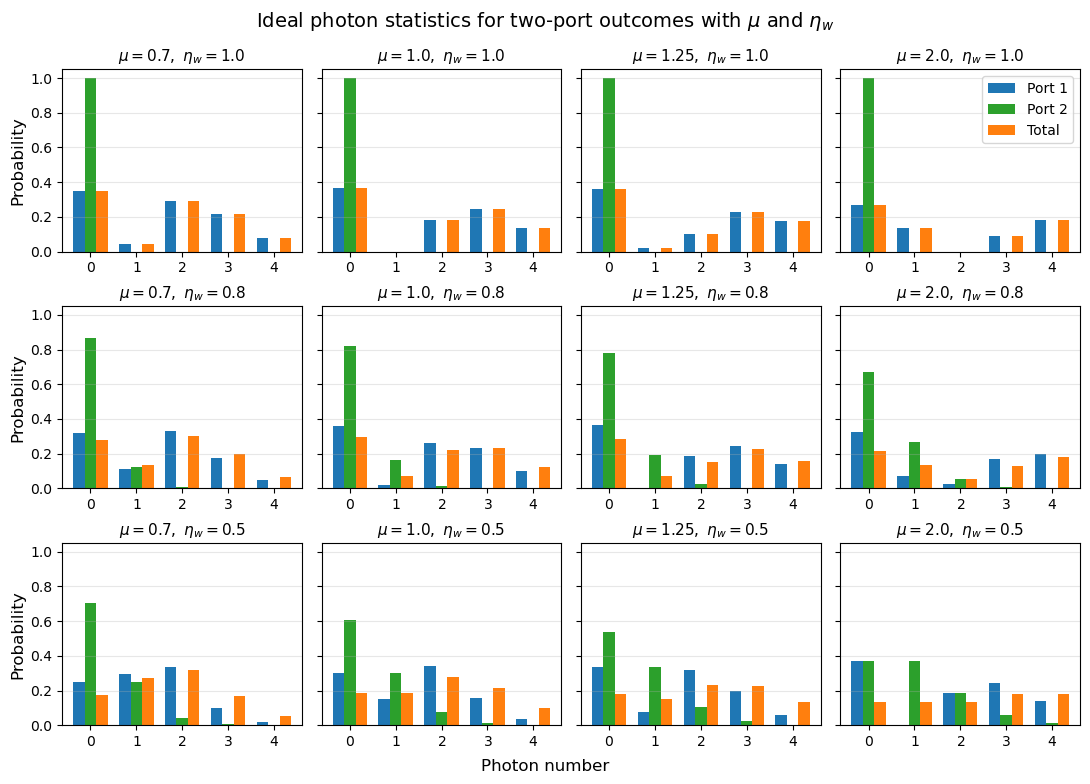

In [30]:
eta_ws = [1.0, 0.8, 0.5]
us = [0.7, 1.0, 1.25, 2.0]  # mu = |alpha|^2
phi_w = 0.0

fig, axes = plt.subplots(len(eta_ws), len(us), figsize=(11, 8), sharex=True, sharey=True)
x, width = np.arange(n_show), 0.25

for i, eta_w in enumerate(eta_ws):
    for j, u in enumerate(us):
        _, p1, p2, p_tot = photon_statistics(
            eta_w=eta_w, u=u, 
            eta_sig=1.0, 
            include_dark=False
        )
        ax = axes[i, j]
        ax.bar(x-width, p1[:n_show], width, label="Port 1", color="tab:blue")
        ax.bar(x, p2[:n_show], width, label="Port 2", color="tab:green")
        ax.bar(x+width, p_tot[:n_show], width, label="Total", color="tab:orange")
        
        ax.set_title(rf"$\mu={u},\ \eta_w={eta_w}$", fontsize=11)
        ax.set_xticks(x, [rf"${n}$" for n in x], fontsize=10)
        ax.tick_params(axis="x", labelbottom=True)
        ax.grid(axis="y", alpha=0.3)

        print(f"\neta_w={eta_w}, mu={u}")
        print("Port 1:", np.round(p1[:n_show], 5))
        print("Port 2:", np.round(p2[:n_show], 5))
        print("Total :", np.round(p_tot[:n_show], 5))

for ax in axes[:, 0]:
    ax.set_ylabel("Probability", fontsize=12)

axes[0, -1].legend(fontsize=10)
fig.supxlabel("Photon number", fontsize=12, y=0.025)
fig.suptitle(r"Ideal photon statistics for two-port outcomes with $\mu$ and $\eta_w$",
             y=0.98, fontsize=14)
fig.tight_layout()
fig.subplots_adjust(hspace=0.3)
fig.savefig("pnr_losses_2port.png", dpi=300, bbox_inches="tight")
plt.show()

##### with losses and dark counts


eta_w=1.0, u=0.7
Port 1: [0.47245 0.29854 0.14954 0.05854 0.01668]
Port 2: [9.9999e-01 1.0000e-05 0.0000e+00 0.0000e+00 0.0000e+00]
Total : [0.47244 0.29854 0.14954 0.05855 0.01668]
P_total(1)=0.298541, <n_total>=0.862020, expected≈0.862020

eta_w=1.0, u=1.0
Port 1: [0.36788 0.30828 0.18394 0.09111 0.03519]
Port 2: [9.9999e-01 1.0000e-05 0.0000e+00 0.0000e+00 0.0000e+00]
Total : [0.36787 0.30828 0.18394 0.09111 0.03519]
P_total(1)=0.308284, <n_total>=1.162020, expected≈1.162020

eta_w=1.0, u=1.25
Port 1: [0.29811 0.30301 0.20389 0.11517 0.05299]
Port 2: [9.9999e-01 1.0000e-05 0.0000e+00 0.0000e+00 0.0000e+00]
Total : [0.2981  0.30301 0.20389 0.11517 0.05299]
P_total(1)=0.303015, <n_total>=1.412020, expected≈1.412020

eta_w=1.0, u=2.0
Port 1: [0.15726 0.24875 0.22682 0.16583 0.10484]
Port 2: [9.9999e-01 1.0000e-05 0.0000e+00 0.0000e+00 0.0000e+00]
Total : [0.15726 0.24874 0.22682 0.16583 0.10484]
P_total(1)=0.248744, <n_total>=2.162020, expected≈2.162020

eta_w=0.8, u=0.7
Port 1: [0.53

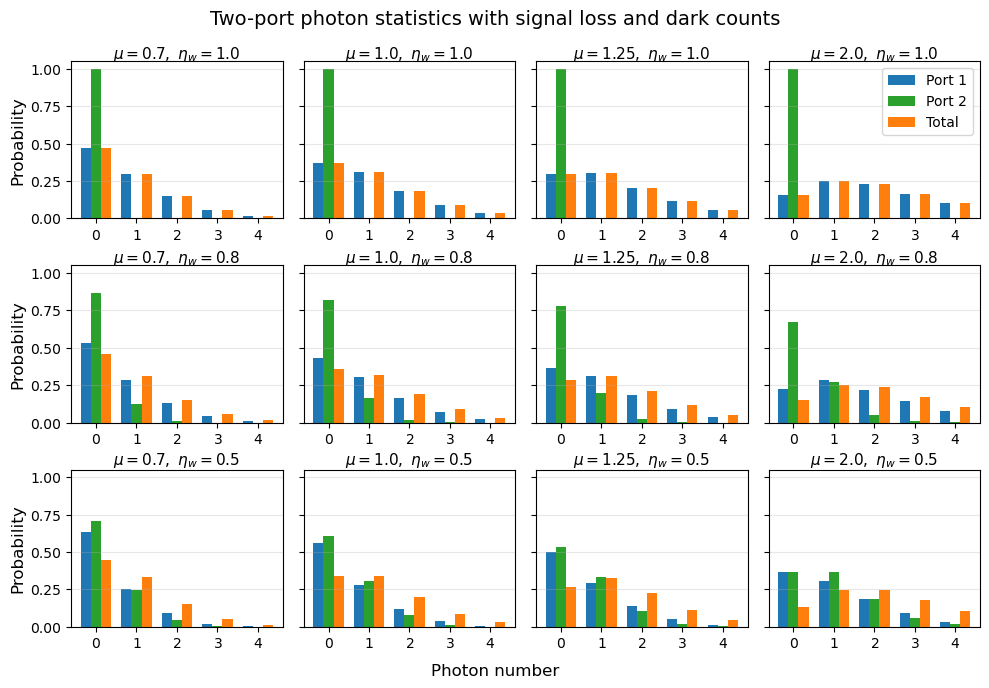

In [31]:
R_dark1 = 100       # Hz
R_dark2 = 100       # Hz
t_on = 100e-9     # s 100ns
lamdk1 = R_dark1 * t_on
lamdk2 = R_dark2 * t_on

eta_pre = 0.2       # signal transmission before displacement
eta_post_opt = 0.9   # detection efficiency after displacement
eta_det = 0.9
eta_signal = eta_pre * eta_post_opt * eta_det

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    len(eta_ws),
    len(us),
    figsize=(10, 7),
    sharex=True,
    sharey=True
)

x = np.arange(n_show)
width = 0.25

for i, eta_w in enumerate(eta_ws):
    for j, u in enumerate(us):
        p_joint, p1, p2, p_tot = photon_statistics(
            eta_w=eta_w, u=u,
            eta_sig=eta_signal,
            include_dark=True,
            lam1=lamdk1, lam2=lamdk2
        )

        ax = axes[i, j]

        ax.bar(x - width, p1[:n_show], width, label="Port 1", color="tab:blue")
        ax.bar(x, p2[:n_show], width, label="Port 2", color="tab:green")
        ax.bar(x + width, p_tot[:n_show], width, label="Total", color="tab:orange")

        ax.set_title(rf"$\mu={u},\ \eta_w={eta_w}$", fontsize=11, pad=2)
        ax.set_xticks(x)
        ax.set_xticklabels([rf"${n}$" for n in x], fontsize=10)

        # Display x-axis numbers in every subplot
        ax.tick_params(axis="x",labelbottom=True)
        ax.grid(axis="y",alpha=0.3)

        mean_total = np.sum(np.arange(len(p_tot)) * p_tot)
        expected_mean = (eta_signal + u + lamdk1 + lamdk2)   # for rough check

        print(f"\neta_w={eta_w}, u={u}")
        print("Port 1:", np.round(p1[:n_show], 5))
        print("Port 2:", np.round(p2[:n_show], 5))
        print("Total :", np.round(p_tot[:n_show], 5))

        print(
            f"P_total(1)={p_tot[1]:.6f}, "
            f"<n_total>={mean_total:.6f}, "
            f"expected≈{expected_mean:.6f}"
        )

for ax in axes[:, 0]:
    ax.set_ylabel("Probability",fontsize=12)

axes[0, -1].legend(fontsize=10)
fig.suptitle(r"Two-port photon statistics with signal loss and dark counts", fontsize=14, y=0.98)
fig.supxlabel("Photon number", fontsize=12, y=0.025)
fig.tight_layout()
fig.subplots_adjust(hspace=0.3, wspace=0.1)

fig.savefig("pnr_loss_dark_2port.png", dpi=300, bbox_inches="tight")
plt.show()

##### One port plot: Lossy, Displacement-only, Corrected Distribution


eta_w=1.0, u=0.7
Lossy   : [0.47245 0.29854 0.14954 0.05854 0.01668]
Disp only: [0.49659 0.34761 0.12166 0.02839 0.00497]
Corrected: [0.34761 0.04469 0.29373 0.21453 0.07729]

eta_w=1.0, u=1.0
Lossy   : [0.36788 0.30828 0.18394 0.09111 0.03519]
Disp only: [0.36788 0.36788 0.18394 0.06131 0.01533]
Corrected: [0.36788 0.      0.18394 0.24525 0.13795]

eta_w=1.0, u=1.25
Lossy   : [0.29811 0.30301 0.20389 0.11517 0.05299]
Disp only: [0.2865  0.35813 0.22383 0.09326 0.02914]
Corrected: [0.35813 0.01791 0.10072 0.2285  0.17633]

eta_w=1.0, u=2.0
Lossy   : [0.15726 0.24875 0.22682 0.16583 0.10484]
Disp only: [0.13534 0.27067 0.27067 0.18045 0.09022]
Corrected: [0.27067 0.13534 0.      0.09022 0.18045]

eta_w=0.8, u=0.7
Lossy   : [0.53049 0.28597 0.12878 0.04281 0.00997]
Disp only: [0.57121 0.31988 0.08957 0.01672 0.00234]
Corrected: [0.31988 0.11059 0.33165 0.17775 0.04946]

eta_w=0.8, u=1.0
Lossy   : [0.43477 0.30414 0.16242 0.06971 0.02233]
Disp only: [0.44933 0.35946 0.14379 0.03834 0.007

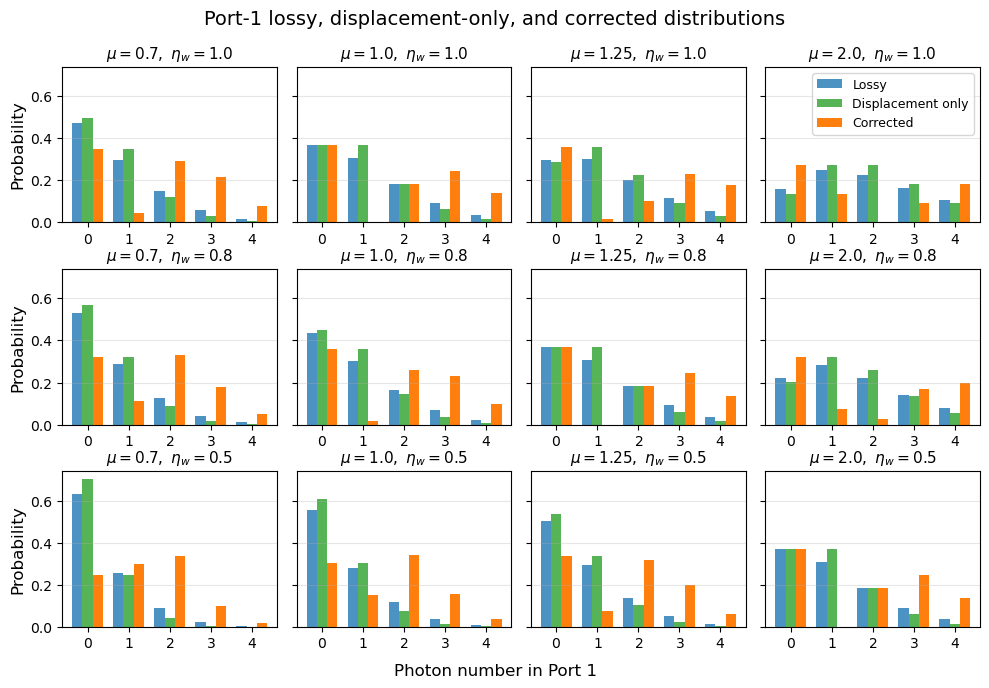

In [32]:
fig, axes = plt.subplots(len(eta_ws), len(us), figsize=(10, 7), sharex=True, sharey=True)
x, width = np.arange(n_show), 0.25

for i, eta_w in enumerate(eta_ws):
    for j, u in enumerate(us):
        _, p1_disp, _, _ = photon_statistics(
            eta_w=eta_w, u=u, 
            eta_sig=0.0,    #input state is ∣0⟩⟨0∣
            include_dark=True
        )
        _, p1_on, _, _ = photon_statistics(
            eta_w=eta_w, u=u, 
            eta_sig=eta_signal, 
            include_dark=True
        )

        p1_corr = (p1_on - (1 - eta_signal) * p1_disp) / eta_signal
        p1_corr = np.clip(p1_corr, 0, None)
        p1_corr /= p1_corr.sum()

        ax = axes[i, j]
        ax.bar(x-width, p1_on[:n_show], width, label="Lossy", color="#4C92C3", alpha=1.0)
        ax.bar(x, p1_disp[:n_show], width, label="Displacement only", color="#56B356", alpha=1.0)
        ax.bar(x+width, p1_corr[:n_show], width, label="Corrected", color="tab:orange")
        ax.set_title(rf"$\mu={u},\ \eta_w={eta_w}$", fontsize=11)
        ax.set_xticks(x, [rf"${n}$" for n in x], fontsize=10)
        ax.tick_params(axis="x", labelbottom=True)
        ax.grid(axis="y", alpha=0.3)

        print(f"\neta_w={eta_w}, u={u}")
        print("Lossy   :", np.round(p1_on[:n_show], 5))
        print("Disp only:", np.round(p1_disp[:n_show], 5))
        print("Corrected:", np.round(p1_corr[:n_show], 5))

for ax in axes[:, 0]:
    ax.set_ylabel("Probability", fontsize=12)

axes[0, -1].legend(fontsize=9)
fig.supxlabel("Photon number in Port 1", fontsize=12, y=0.025)
fig.suptitle(r"Port-1 lossy, displacement-only, and corrected distributions",
             y=0.98, fontsize=14)
fig.tight_layout()
fig.subplots_adjust(hspace=0.3)
fig.savefig("pnr_port1_loss_corr.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. 4-pixel detectors

##### with losses and dark counts

$|1\rangle$
$\xrightarrow{\eta_{\rm pre}}$
$\rho_{\rm in}$
$\xrightarrow{W^{-1}D(\alpha)W}$
$P(n_1,n_2)$
$\xrightarrow{\eta_{\rm post}}$
$P_{\rm loss}(n_1,n_2)$
$\xrightarrow{R_4(\eta_d)}$
$P(c_1,c_2)$
$\xrightarrow{\rm dark}$
$P_{\rm meas}(c_1,c_2)$

In [33]:
N = 20     # Fock-space cutoff
n_show = 5
M = 4      # Detector pixels

eta_ws = [1.0, 0.8, 0.5]  #α=actual injected displacement after the BS.
us = [0.7, 1.0, 1.25, 2.0]

eta_pre  = 0.20*0.99      # signal survival BEFORE displacement, 0.99 BS ratio
eta_post = 0.95      # optical transmission AFTER displacement
eta_d    = 0.90      # detector efficiency

R_dark = 100         # Hz per 4-pixel detector
tau = 100e-9

vac, one = basis(N,0), basis(N,1)

h = tensor(destroy(N), qeye(N))
v = tensor(qeye(N), destroy(N))

# W
theta = np.arccos(np.sqrt(eta_w))
W = (theta * (h.dag()*v - h*v.dag())).expm()

# displacement on H mode
D = tensor(displace(N, alpha), qeye(N))

def W_operator(eta_w, phi=0.0):
    """
    W|1_H,0_V> =
        sqrt(eta_w)|1_H,0_V>
        + exp(i phi)sqrt(1-eta_w)|0_H,1_V>.
    """
    theta = np.arccos(np.sqrt(eta_w))

    G = theta * (
        np.exp(1j * phi) * v.dag() * h
        - np.exp(-1j * phi) * h.dag() * v
    )

    return G.expm()


# ---------- optical loss: P(n) -> P(m) ----------
def loss_response(eta):
    return np.array([
        [
            comb(n, m) * eta**m * (1-eta)**(n-m)
            if m <= n else 0
            for n in range(N)
        ]
        for m in range(N)
    ])


# ---------- 4-pixel detector ----------
def detector_response(eta_d):
    return np.array([
        [
            comb(M,c) * sum(
                (-1)**j * comb(c,j)
                * (1 - eta_d + eta_d*(c-j)/M)**n
                for j in range(c+1)
            )
            for n in range(N)
        ]
        for c in range(M+1)
    ])


# ---------- dark counts ----------
def dark_response(R_dark):
    p_dark = 1 - np.exp(-R_dark * tau / M)

    A = np.zeros((M+1, M+1))

    for c in range(M+1):
        for k in range(c, M+1):
            d = k - c
            A[k,c] = (
                comb(M-c, d)
                * p_dark**d
                * (1-p_dark)**(M-c-d)
            )

    return A


# ---------- simulation ----------
def simulate(signal_on, eta_w, mu,
             eta_pre, eta_post, eta_d, R_dark, phi = 0.0):

    W = W_operator(eta_w, phi)

    # displacement-point amplitude
    alpha = np.sqrt(mu)
    D = tensor(displace(N, alpha), qeye(N))

    # state BEFORE displacement
    if signal_on:
        rho_in = (
            eta_pre * ket2dm(tensor(one, vac))
            + (1-eta_pre) * ket2dm(tensor(vac, vac))
        )
    else:
        rho_in = ket2dm(tensor(vac, vac))

    # W -> displacement -> W^-1
    rho = W * rho_in * W.dag()
    rho = D * rho * D.dag()
    rho = W.dag() * rho * W

    # ideal photon-number distribution
    P_n = np.real(np.diag(rho.full())).reshape(N, N)
    P_n = np.clip(P_n, 0, None)   #numerical clean up
    P_n /= P_n.sum()

    # post-displacement optical loss
    L = loss_response(eta_post)
    P_loss = L @ P_n @ L.T

    # 4-pixel detector efficiency + collision
    R = detector_response(eta_d)
    P_click = R @ P_loss @ R.T

    # dark counts
    A = dark_response(R_dark)
    P_click = A @ P_click @ A.T

    P1 = P_click.sum(axis=1)
    P2 = P_click.sum(axis=0)

    return P_n, P1, P2, P_click

##### 2.1 Plots of displacement only, 4-pixel, with loss and dark counts

Detector 1 ideal: [0.36787944 0.41794845 0.17806197 0.03371608 0.00239406]
Detector 2 ideal: [1. 0. 0. 0. 0.]
Detector 1 real: [0.44485362 0.39941297 0.13448024 0.0201239  0.00112927]
Detector 2 real: [9.99990000e-01 9.99991250e-06 3.74997187e-11 6.24996094e-17
 3.90623047e-23]


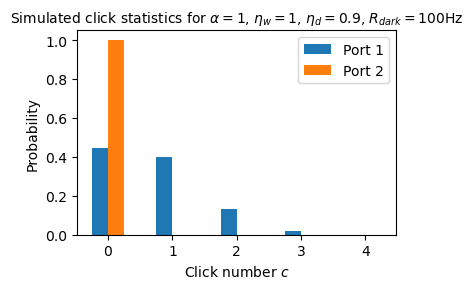

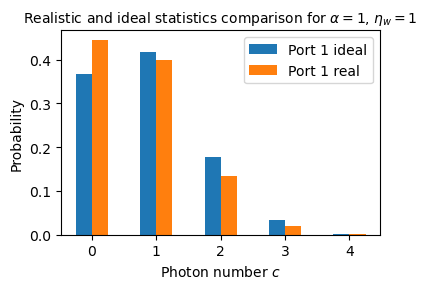

In [34]:
# displacement only
P_n_ideal, P1_disp_ideal, P2_disp_ideal, __ = simulate(
    eta_w = 1.0,
    mu = 1.0,
    signal_on=False,
    eta_pre=1.0,
    eta_post=1.0,
    eta_d=1.0,
    R_dark=0
)

P_n_ideal, P1_disp_real, P2_disp_real, __ = simulate(
    eta_w = 1.0,
    mu = 1.0,
    signal_on=False,
    eta_pre=0.2, # doesnt matter for displacement only
    eta_post=0.9, 
    eta_d=0.9,
    R_dark=100
)

print("Detector 1 ideal:", P1_disp_ideal) 
print("Detector 2 ideal:", P2_disp_ideal) 
print("Detector 1 real:", P1_disp_real)
print("Detector 2 real:", P2_disp_real)

c, w = np.arange(n_show), 0.25

# Both ports realistic click statistics
plt.figure(figsize=(4, 3))
plt.bar(c - w/2, P1_disp_real, width=w, label="Port 1")
plt.bar(c + w/2, P2_disp_real, width=w, label="Port 2")

plt.title(r"Simulated click statistics for $\alpha=1$, $\eta_w=1$, $\eta_d=0.9$, $R_{dark}=100$Hz", fontsize=10)
plt.xlabel("Click number $c$")
plt.ylabel("Probability")
plt.xticks(c)
plt.legend()
plt.tight_layout()
plt.show()

# port 1 ideal vs real
plt.figure(figsize=(4, 3))
plt.bar(c - w/2, P1_disp_ideal, width=w, label="Port 1 ideal")
plt.bar(c + w/2, P1_disp_real, width=w, label="Port 1 real")
plt.title(r"Realistic and ideal statistics comparison for $\alpha=1$, $\eta_w=1$", fontsize=10)
plt.xlabel("Photon number $c$")
plt.ylabel("Probability")
plt.xticks(c)
plt.legend()
plt.tight_layout()
plt.show()


##### 2.2 4-pixel, 1 port, with loss and dark counts, various 'eta' and 'mu'

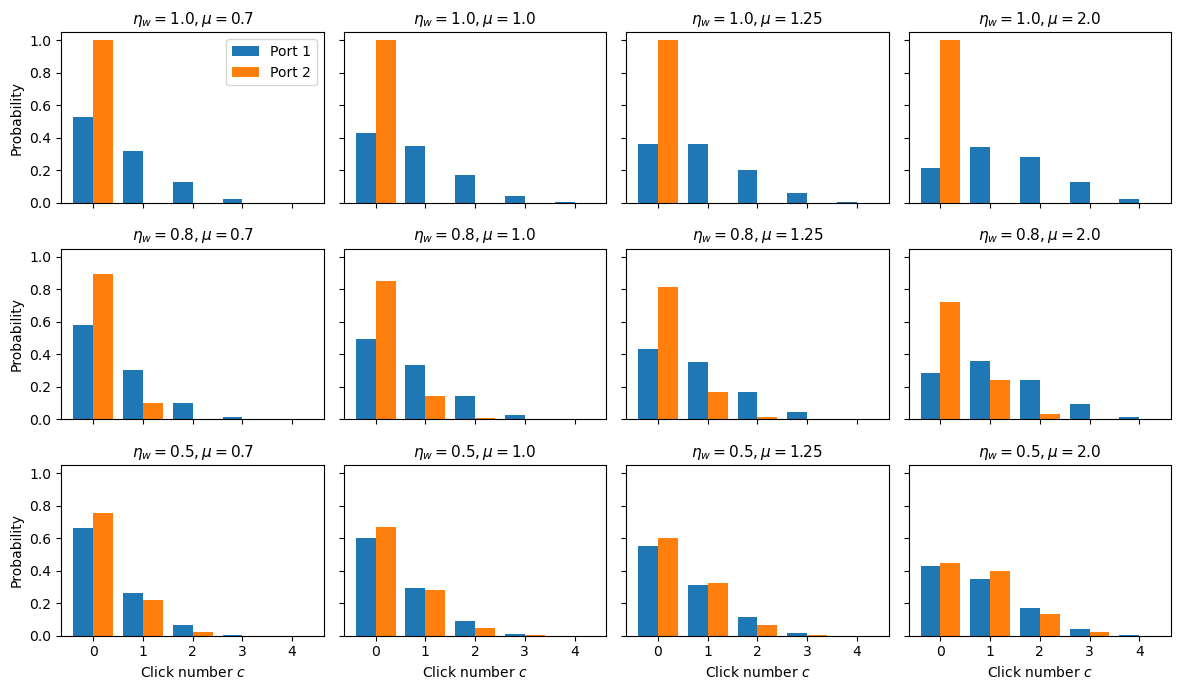

In [40]:
eta_ws = [1.0, 0.8, 0.5]
us = [0.7, 1.0, 1.25, 2.0]  # u = |alpha|^2

fig, axes = plt.subplots(
    len(eta_ws), len(us),
    figsize=(12, 7),
    sharex=True,
    sharey=True
)

c = np.arange(n_show)
w = 0.4

for i, eta_w in enumerate(eta_ws):
    for j, u in enumerate(us):

        P_n_real, P1_sig_real, P2_sig_real, __ = simulate(
            eta_w=eta_w,
            mu=u,
            signal_on=True,
            eta_pre=0.2,
            eta_post=0.9,
            eta_d=0.9,
            R_dark=100
        )

        ax = axes[i, j]

        ax.bar(c - w/2, P1_sig_real, width=w, label="Port 1")
        ax.bar(c + w/2, P2_sig_real, width=w, label="Port 2")

        ax.set_title(
            rf"$\eta_w={eta_w},\mu={u}$",
            fontsize=11
        )

        ax.set_xticks(c)

        if j == 0:
            ax.set_ylabel("Probability")

        if i == len(eta_ws) - 1:
            ax.set_xlabel("Click number $c$")

axes[0, 0].legend(fontsize=10)


plt.tight_layout()
plt.show()

##### 4-pixel, port 1, displacement and signal, with loss and correction

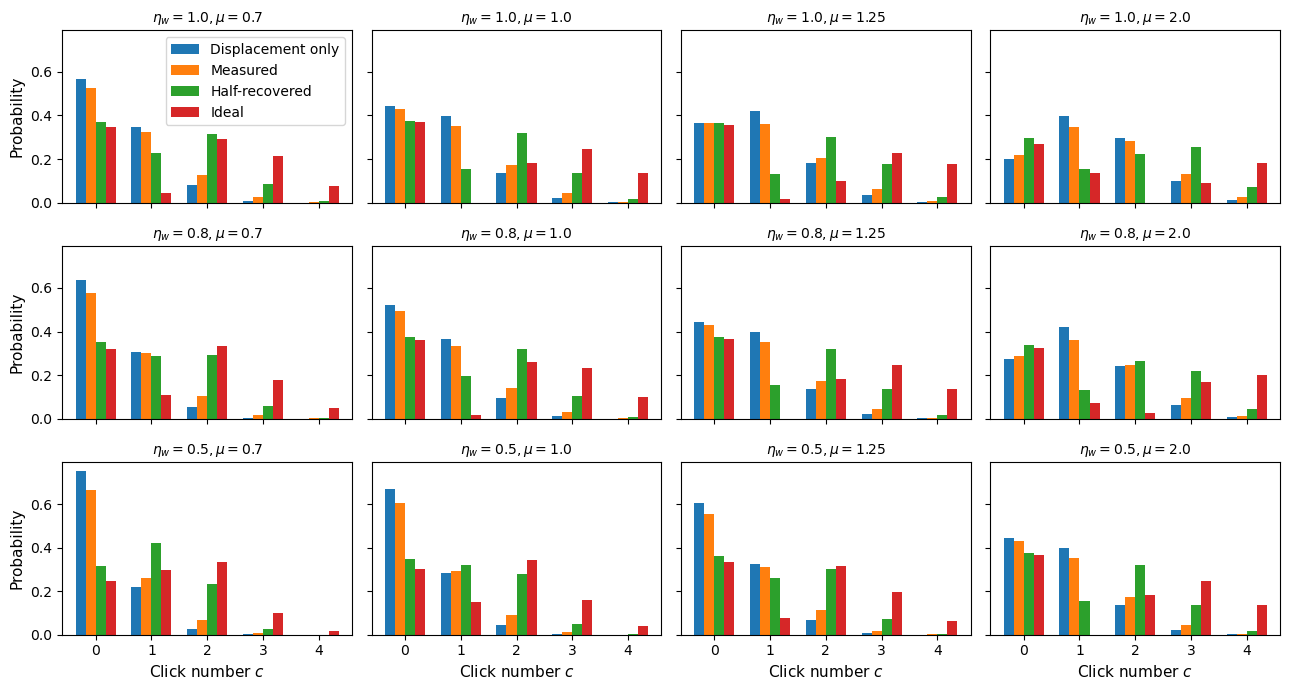

In [43]:
def recover(P_on, P_disp, eta_pre):
    """
    Recover click distribution conditioned on the single photon
    having survived to the displacement point.

    P_on   : signal + displacement click distribution
    P_disp : displacement-only click distribution
    eta_pre: signal survival probability before displacement
    """
    P_corr = (
        P_on - (1 - eta_pre) * P_disp
    ) / eta_pre

    return P_corr

eta_ws = [1.0, 0.8, 0.5]
us = [0.7, 1.0, 1.25, 2.0]
eta_pre, eta_post, eta_d, R_dark = 0.2, 0.9, 0.9, 100

fig, axes = plt.subplots(len(eta_ws), len(us), figsize=(13, 7), sharex=True, sharey=True)
c, w = np.arange(n_show), 0.18

for i, eta_w in enumerate(eta_ws):
    for j, u in enumerate(us):
        #_, P1_ideal, _, __ = simulate(eta_w=eta_w, mu=u, signal_on=True, eta_pre=1.0, eta_post=1.0, eta_d=1.0, R_dark=0)
        
        P_n_ideal, _, _, __ = simulate(
            eta_w=eta_w, mu=u, signal_on=True,
            eta_pre=1.0, eta_post=1.0, eta_d=1.0, R_dark=0)
        P1_ideal = P_n_ideal.sum(axis=1)

        _, P1_real, _, __ = simulate(eta_w=eta_w, mu=u, signal_on=True, eta_pre=eta_pre, eta_post=eta_post, eta_d=eta_d, R_dark=R_dark)
        _, P1_disp, _, __ = simulate(eta_w=eta_w, mu=u, signal_on=False, eta_pre=eta_pre, eta_post=eta_post, eta_d=eta_d, R_dark=R_dark)

        P1_corr = recover(P1_real, P1_disp, eta_pre)
        
        ax = axes[i, j]
        ax.bar(c-1.5*w, P1_disp[:n_show], width=w, label="Displacement only")
        ax.bar(c-0.5*w, P1_real[:n_show], width=w, label="Measured")
        ax.bar(c+0.5*w, P1_corr[:n_show], width=w, label="Half-recovered")
        ax.bar(c+1.5*w, P1_ideal[:n_show], width=w, label="Ideal")
        ax.set_title(rf"$\eta_w={eta_w},\mu={u}$", fontsize=10)
        ax.set_xticks(c)
        
        if j == 0: ax.set_ylabel("Probability", fontsize=11)
        if i == len(eta_ws)-1: ax.set_xlabel("Click number $c$", fontsize=11)

axes[0, 0].legend(fontsize=10)
plt.tight_layout()
plt.show()

##### Selected plots for proposal

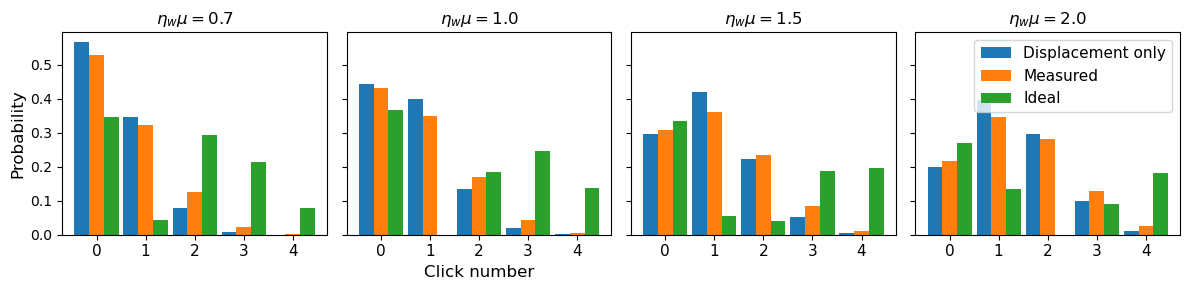

In [61]:
cases = [(1.0, 0.7), (1.0, 1.0), (1.0, 1.5), (1.0, 2.0)]
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
n = np.arange(n_show)
w = 0.3

for ax, (eta_w, u) in zip(axes, cases):

    P_n_ideal, _, _, __ = simulate(
                eta_w=eta_w, mu=u, signal_on=True,
                eta_pre=1.0, eta_post=1.0, eta_d=1.0, R_dark=0)
    P1_ideal = P_n_ideal.sum(axis=1)
    
    _, P1_real, _, __ = simulate(eta_w=eta_w, mu=u, signal_on=True, eta_pre=eta_pre, eta_post=eta_post, eta_d=eta_d, R_dark=R_dark)
    _, P1_disp, _, __ = simulate(eta_w=eta_w, mu=u, signal_on=False, eta_pre=eta_pre, eta_post=eta_post, eta_d=eta_d, R_dark=R_dark)
    
    ax.bar(c-w, P1_disp[:n_show], width=w, label="Displacement only")
    ax.bar(c, P1_real[:n_show], width=w, label="Measured")
    ax.bar(c+w, P1_ideal[:n_show], width=w, label="Ideal")

    ax.set_title(rf"$\eta_w\mu={eta_w*u}$", fontsize=12)
    ax.set_xticks(n)
    ax.tick_params(axis='x', labelsize=11)

axes[1].set_xlabel("Click number", fontsize=12)
axes[0].set_ylabel("Probability", fontsize=12)
axes[3].legend(fontsize=11)
plt.tight_layout()
plt.savefig("4px_port1_loss_corr.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3. Possible simulated counts results

counts = [40668 40889 15585  2697   161]
P_meas = [0.40668 0.40889 0.15585 0.02697 0.00161]
true alpha = 1.0
fitted alpha = 1.001390073304027


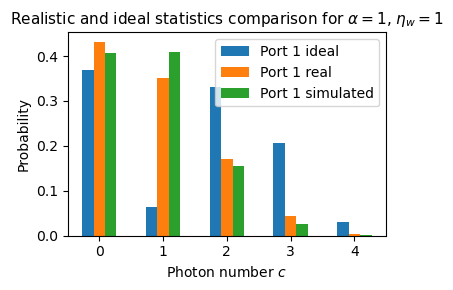

In [37]:
from scipy.optimize import minimize_scalar

M = 4
eta_d = 0.9
R_dark = 100
tau = 100e-9
N_trial = 100000

def click_prob(alpha):
    # coherent state: detected mean photon number
    mu = eta_d * abs(alpha)**2

    # signal click probability per pixel
    p_sig = 1 - np.exp(-mu/M)

    # dark-click probability per pixel
    p_dark = 1 - np.exp(-R_dark*tau/M)

    # either signal or dark gives a click
    p = 1 - (1-p_sig)*(1-p_dark)

    return np.array([
        
        comb(M,c) * p**c * (1-p)**(M-c)
        for c in range(M+1)
    ])

# -------------------------
# simulate experimental data
# -------------------------
alpha_true = 1.0
P_true = click_prob(alpha_true)

counts = np.random.multinomial(N_trial, P_true)
P_meas = counts / N_trial

print("counts =", counts)
print("P_meas =", P_meas)

# -------------------------
# fit alpha
# -------------------------
def neg_log_likelihood(alpha):
    P = np.clip(click_prob(alpha), 1e-15, 1)
    return -np.sum(counts * np.log(P))

fit = minimize_scalar(
    neg_log_likelihood,
    bounds=(0, 3),
    method="bounded"
)

alpha_fit = fit.x

print("true alpha =", alpha_true)
print("fitted alpha =", alpha_fit)

plt.figure(figsize=(4, 3))
plt.bar(c - w, P1_ideal, width=w, label="Port 1 ideal")
plt.bar(c, P1_real, width=w, label="Port 1 real")
plt.bar(c + w, P_meas, width=w, label="Port 1 simulated")
plt.title(r"Realistic and ideal statistics comparison for $\alpha=1$, $\eta_w=1$", fontsize=11)
plt.xlabel("Photon number $c$")
plt.ylabel("Probability")
plt.xticks(c)
plt.legend()
plt.tight_layout()
plt.show()